In [1]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import pandas as pd
from IPython.display import JSON
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from functools import partial
from src.jsonl_dataset import JsonLDataset

In [2]:
# Raw dataset
path = kagglehub.dataset_download("Cornell-University/arxiv/versions/272")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
ds = JsonLDataset(ds_path)

# Categories hierarchy
categories_hierarchy = json.load(open("resources/categories_hierarchy.json", 'r'))

# Augmented index
df = pd.read_json("resources/augmented_index.jsonl", lines=True)
df.columns = ["Index", "Raw categories", "Parent categories", "Remapped categories"]

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.


# Data Selection for the Parent Categories Classification

In [3]:
def filter_by_parent_category(df: pd.DataFrame, c_filter: str) -> pd.DataFrame:
    return df[df["Parent categories"].apply(lambda categories: c_filter in categories)].reset_index(drop=True)

In [8]:
df_parents = {}
for k in tqdm(categories_hierarchy.keys()):
    df_filtered = filter_by_parent_category(df, k)
    df_parents[k] = df_filtered

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:18<00:00,  2.05s/it]


In [16]:
# Integrity check
def integrity_check(df_parents, categories_hierarchy):
    print("Checking data integrity")
    error = False
    for key, df in tqdm(df_parents.items()):
        total_count_in_categories = categories_hierarchy[key]["count"]
        parent_categories_count = df["Parent categories"].apply(lambda c: c.count(key)).sum()
        if total_count_in_categories != parent_categories_count:
            print(f"""
                Missmatch in tags count for parent category: {key}
                Found: {total_count_in_categories} tags in categories_hierarchy
                And    {parent_categories_count} tags in the augmented index
            """)
            error = True
    if not error:
        print("Alles gut :D")

integrity_check(df_parents, categories_hierarchy)

Checking data integrity


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:04<00:00,  2.22it/s]

Alles gut:D


In [233]:
def plot_parent_distribution(df_parents: dict[str, "pd.DataFrame"], title: str) -> None:
    """
    Creates an interactive bar chart showing the number of samples per parent category.
    """
    import plotly.graph_objects as go

    labels = list(df_parents.keys())
    values = [len(df) for df in df_parents.values()]

    sorted_pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
    labels, values = zip(*sorted_pairs)

    fig = go.Figure(
        data=go.Bar(
            x=list(labels),
            y=list(values),
            marker_color=[
                "#636EFA", "#EF553B", "#00CC96", "#AB63FA",
                "#FFA15A", "#19D3F3", "#FF6692", "#B6E880",
            ][:len(labels)],
            hovertemplate="<b>%{x}</b><br>Count: %{y:,}<extra></extra>",
        )
    )

    fig.update_layout(
        title=f"Subcategories inside the {title} Category",
        xaxis_title="Parent Category",
        yaxis_title="Number of Samples",
        yaxis_tickformat=",",
        template="plotly_white",
        height=700,
    )

    fig.show()

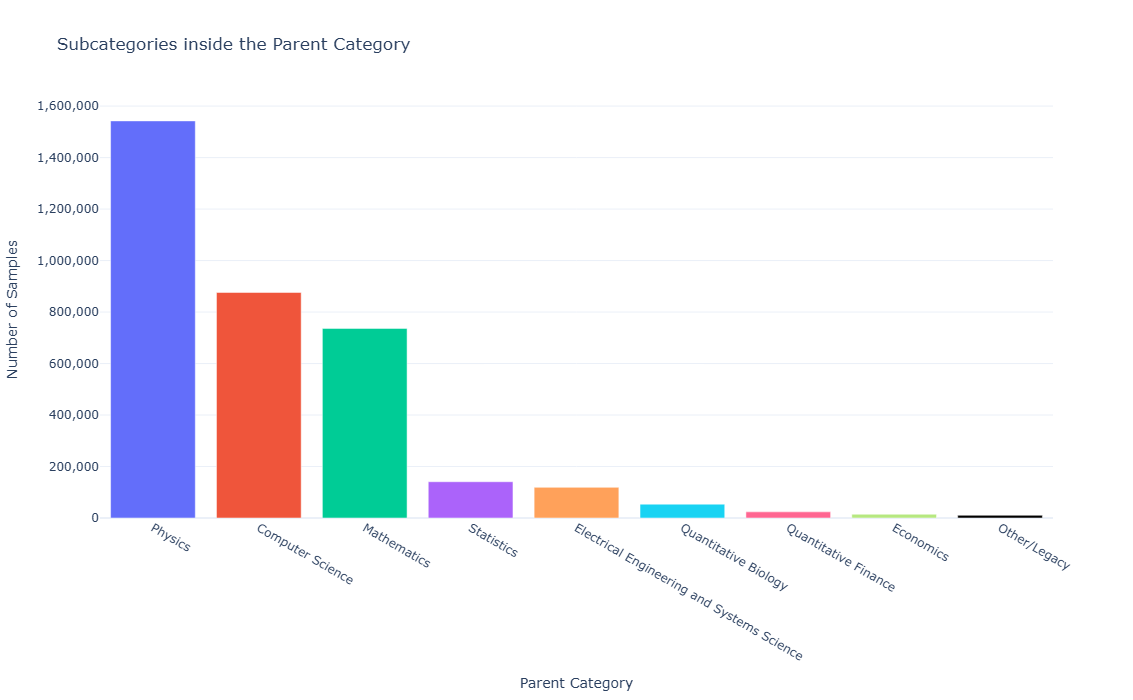

In [342]:
plot_parent_distribution(df_parents, "Parent")

In [178]:
def save_indices_to_jsonl(indices_array, output_path):   
    with open(output_path, 'w') as f:
        for row in indices_array:
            # Dump the list directly. No dictionary wrapper.
            f.write(json.dumps(row.tolist()) + '\n')

In [302]:
def sample_indices_from_df(
    df_parents: dict[str, pd.DataFrame],
    n_samples_per_class: int = 10_000,
    n_test_per_class: int = 2_000,
    random_state: int | None = None,
    classes_to_skip: list[str] = [],
    save_path_train: str = None,
    save_path_test: str = None,
    existing_test_indices: np.ndarray | None = None  # New Parameter
) -> tuple[np.ndarray, np.ndarray]:
    
    rng = np.random.default_rng(random_state)
    train_indices = []
    test_indices = []
    
    # Convert existing_test_indices to a set for O(1) lookups if provided
    # Flattening it handles the 2D array structure mentioned in your docstring
    forbidden_set = set(existing_test_indices.flatten()) if existing_test_indices is not None else set()

    for key, parent_df in df_parents.items():
        if key in classes_to_skip:
            continue
            
        # 1. Get all available indices
        all_idx = parent_df["Index"].values
        
        # 2. Filter out existing test indices to ensure disjoint sets
        # This keeps only indices NOT in our forbidden set
        mask = np.isin(all_idx, list(forbidden_set), invert=True)
        available_idx = all_idx[mask]
        
        n_available = len(available_idx)
        order = rng.permutation(n_available)
        
        # 3. Sample Train
        n_train = min(n_samples_per_class, n_available)
        train_indices.append(available_idx[order[:n_train]].tolist())
        
        # 4. Sample Test only if no existing test indices were provided
        if existing_test_indices is None:
            n_test = min(n_test_per_class, n_available - n_train)
            test_indices.append(available_idx[order[n_train : n_train + n_test]].tolist())

    # Convert to 2D numpy arrays
    train_indices = np.array(train_indices)
    
    # 5. Determine final test indices and handle saving
    if existing_test_indices is not None:
        final_test_indices = existing_test_indices
    else:
        final_test_indices = np.array(test_indices)
        # Only save test indices if we actually generated new ones
        save_indices_to_jsonl(final_test_indices, save_path_test)

    # Always save train indices
    save_indices_to_jsonl(train_indices, save_path_train)
    
    return train_indices, final_test_indices

In [323]:
train_indices, test_indices = sample_indices_from_df(
    df_parents, n_samples_per_class=10_000, n_test_per_class=2_000, random_state=42, 
    classes_to_skip=["Other/Legacy"], 
    save_path_train="resources/train_indicies_parent_categories.jsonl",
    save_path_test="resources/test_indices_parent_categories.jsonl"
)
print(f"Train: {sum(len(row) for row in train_indices)} indices")
print(f"Test: {sum(len(row) for row in test_indices)} indices")

Train: 80000 indices
Test: 16000 indices


In [324]:
train_indices_bucket2, _ = sample_indices_from_df(
    df_parents, n_samples_per_class=10_000, n_test_per_class=2_000, random_state=43, 
    classes_to_skip=["Other/Legacy"], 
    save_path_train="resources/train_indicies_parent_categories_b2.jsonl",
    save_path_test="resources/test_indices_parent_categories.jsonl",
    existing_test_indices=test_indices
)

In [343]:
train_indices_bucket3, _ = sample_indices_from_df(
    df_parents, n_samples_per_class=10_000, n_test_per_class=2_000, random_state=44, 
    classes_to_skip=["Other/Legacy"], 
    save_path_train="resources/train_indicies_parent_categories_b3.jsonl",
    save_path_test="resources/test_indices_parent_categories.jsonl",
    existing_test_indices=test_indices
)

In [327]:
len(np.intersect1d(train_indices_bucket2.flatten(), test_indices.flatten()))

0

### Manual Validation

In [341]:
from sklearn.metrics import f1_score
f1_score([[0,0,0,0,1,0,0,1]], [[0,0,0,0,1,0,0,1]],average="micro")

1.0

In [301]:
test_indices

array([[ 247323, 2909717, 2940724, ..., 2357389, 1555020, 1827717],
       [1429682,  393177, 1832249, ..., 1299247, 1503272, 1762709],
       [2335404, 2273941, 2403905, ...,   29086, 1521401,  943035],
       ...,
       [1156520, 2620950, 1419424, ..., 2685248, 2534588, 1458718],
       [1455760, 1964673, 1774014, ..., 1981909, 2039949, 2077404],
       [2048620, 2225116, 1647851, ..., 1866255, 1504488, 2054622]])

### Manual checks

In [181]:
categories_hierarchy.keys()

dict_keys(['Physics', 'Mathematics', 'Computer Science', 'Quantitative Biology', 'Statistics', 'Quantitative Finance', 'Economics', 'Electrical Engineering and Systems Science', 'Other/Legacy'])

In [167]:
rand_idx = random.choice(test_indices[1])
print(df.iloc[rand_idx])
print("\n\n")
print(json.dumps(ds[rand_idx], indent=4))

Index                                               219082
Raw categories                     math-ph math.AP math.MP
Parent categories      [Physics, Mathematics, Mathematics]
Remapped categories            [math-ph, math.AP, math.MP]
Name: 219082, dtype: object



{
    "id": "1010.2694",
    "submitter": "Vincent Duch\\^ene M.",
    "authors": "Vincent Duch\\^ene, Michael I. Weinstein",
    "title": "Scattering, homogenization and interface effects for oscillatory\n  potentials with strong singularities",
    "comments": "To appear in SIAM Multiscale Modeling, Analysis and Simulation (2011)",
    "journal-ref": "Multiscale Model. Simul., 9, pp. 1017-1063 (2011)",
    "doi": "10.1137/100811672",
    "report-no": null,
    "categories": "math-ph math.AP math.MP",
    "license": "http://arxiv.org/licenses/nonexclusive-distrib/1.0/",
    "abstract": "  We study one-dimensional scattering for a decaying potential with rapid\nperiodic oscillations and strong localized singularities. In pa

# Data selection for the Sub Categories Classification

In [198]:
def extract_nested_tags(data):
    all_tags = []
    
    # Check if 'subgroups' exists to avoid errors
    if 'subgroups' in data:
        # Iterate over each subgroup (e.g., 'physics', 'cond-mat')
        for subgroup_name, subgroup_data in data['subgroups'].items():
            # Check if this subgroup has a 'tags' dictionary
            if 'tags' in subgroup_data:
                # Add all keys from the 'tags' dictionary to our list
                all_tags.extend(subgroup_data['tags'].keys())
                
    return all_tags

In [206]:
def plot_sub_categories_count(data_dict, title="Sub categories count", xlabel="Category", ylabel="Count"):
    if not data_dict:
        print("Dictionary is empty.")
        return

    # 1. Calculate lengths: Create a list of (key, length) tuples
    data = [(k, len(v)) for k, v in data_dict.items()]
    
    # 2. Sort by length (Descending) for better readability
    data.sort(key=lambda x: x[1], reverse=True)
    
    # 3. Unzip into two separate lists for plotting
    labels, values = zip(*data)
    
    # 4. Plotting
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color='skyblue', edgecolor='black')
    
    # Add labels and titles
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    # Rotate x-axis labels if there are many keys
    plt.xticks(rotation=45, ha='right')
    
    # 5. Add value text on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

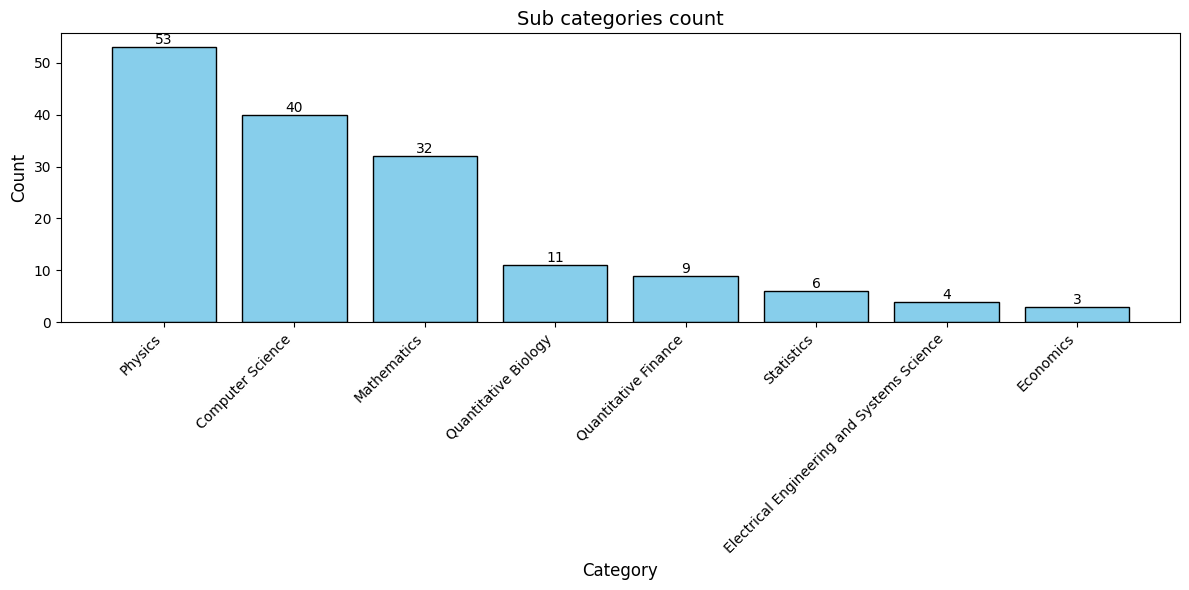

In [207]:
plot_sub_categories_count(TARGET_SUB_CLASSES)

In [211]:
TARGET_SUB_CLASSES = {}

for cat_name in categories_hierarchy.keys():
    if cat_name == "Other/Legacy":
        continue
    nested_tags = extract_nested_tags(categories_hierarchy[cat_name])
    TARGET_SUB_CLASSES[cat_name] = nested_tags

json.dump(TARGET_SUB_CLASSES, open("resources/target_sub_classes.json", "w"))

In [217]:
def filter_by_sub_category(df: pd.DataFrame, c_filter: str) -> pd.DataFrame:
    return df[df["Raw categories"].apply(lambda raw_categories: c_filter in raw_categories.split())].reset_index(drop=True)

In [240]:
def create_dfs_for_sub_category(df, parent_cat):
    result = {}
    sub_classes = TARGET_SUB_CLASSES[parent_cat]
    min_count = 1_000_000
    
    for sub_class in tqdm(sub_classes):
        result[sub_class] = filter_by_sub_category(df, sub_class)
        min_count = min(min_count, len(result[sub_class]))
    return result, min_count

In [242]:
sub_class_dataframes = {}
smallest_subcats = []

for parent_cat_name in TARGET_SUB_CLASSES.keys():
    df_created, smallest_subcat_size = create_dfs_for_sub_category(df, parent_cat_name)
    sub_class_dataframes[parent_cat_name] = df_created
    smallest_subcats.append(smallest_subcat_size)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:10<00:00,  2.67s/it]


In [249]:
for parent_cat_name, df_subcats in sub_class_dataframes.items():
    sample_indices_from_df(
        df_subcats, n_samples_per_class=1_000, n_test_per_class=200, random_state=42, 
        classes_to_skip=["cs.GL"], 
        save_path_train=f"resources/train_indicies_{parent_cat_name}_categories.jsonl",
        save_path_test=f"resources/test_indices_{parent_cat_name}_categories.jsonl"
    )

In [270]:
df_created['eess.IV']

,Index,Raw categories,Parent categories,Remapped categories
0,225881,cs.CV cs.GR eess.IV,"[Computer Science, Computer Science, Electrica...","[cs.CV, cs.GR, eess.IV]"
1,292514,cs.CV cs.CR cs.IT cs.MM eess.IV math.IT,"[Computer Science, Computer Science, Computer ...","[cs.CV, cs.CR, cs.IT, cs.MM, eess.IV, math.IT]"
2,299326,cs.CV cs.CR eess.IV,"[Computer Science, Computer Science, Electrica...","[cs.CV, cs.CR, eess.IV]"
3,356341,cs.CV cs.LG eess.IV q-bio.CB stat.ML,"[Computer Science, Computer Science, Electrica...","[cs.CV, cs.LG, eess.IV, q-bio.CB, stat.ML]"
4,436787,math.ST cs.CV eess.IV stat.TH,"[Mathematics, Computer Science, Electrical Eng...","[math.ST, cs.CV, eess.IV, stat.TH]"
...,...,...,...,...
30035,2536558,eess.IV,[Electrical Engineering and Systems Science],[eess.IV]
30036,2536565,eess.IV cs.CV,"[Electrical Engineering and Systems Science, C...","[eess.IV, cs.CV]"
30037,2536810,eess.IV cs.AI cs.CV cs.LG physics.med-ph,"[Electrical Engineering and Systems Science, C...","[eess.IV, cs.AI, cs.CV, cs.LG, physics.med-ph]"
30038,2537095,eess.IV cs.CV,"[Electrical Engineering and Systems Science, C...","[eess.IV, cs.CV]"


!! Only one category is below 1k Samples, so we will use 1K samples per tag, to do the sampling, and we'll skip the cs.GL category.

In [243]:
smallest_subcats

[1639, 4122, 226, 1356, 1596, 2137, 3699, 20825]

In [244]:
sub_class_dataframes.keys()

dict_keys(['Physics', 'Mathematics', 'Computer Science', 'Quantitative Biology', 'Statistics', 'Quantitative Finance', 'Economics', 'Electrical Engineering and Systems Science'])

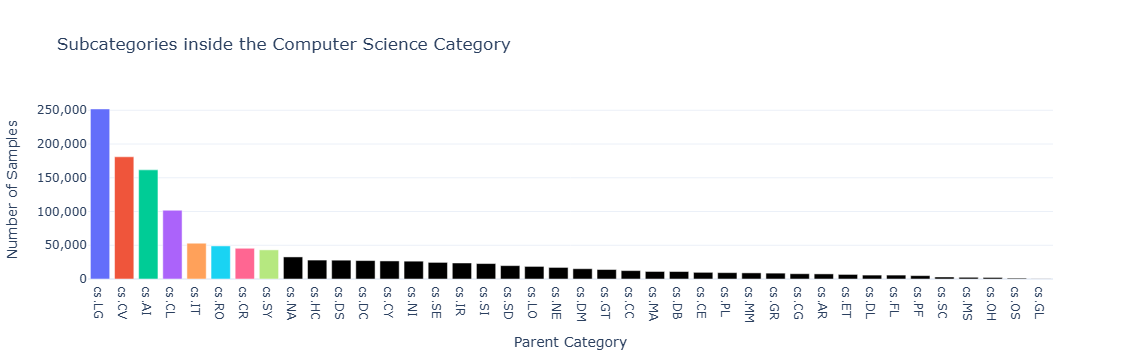

In [245]:
plot_parent_distribution(sub_class_dataframes['Computer Science'], 'Computer Science')

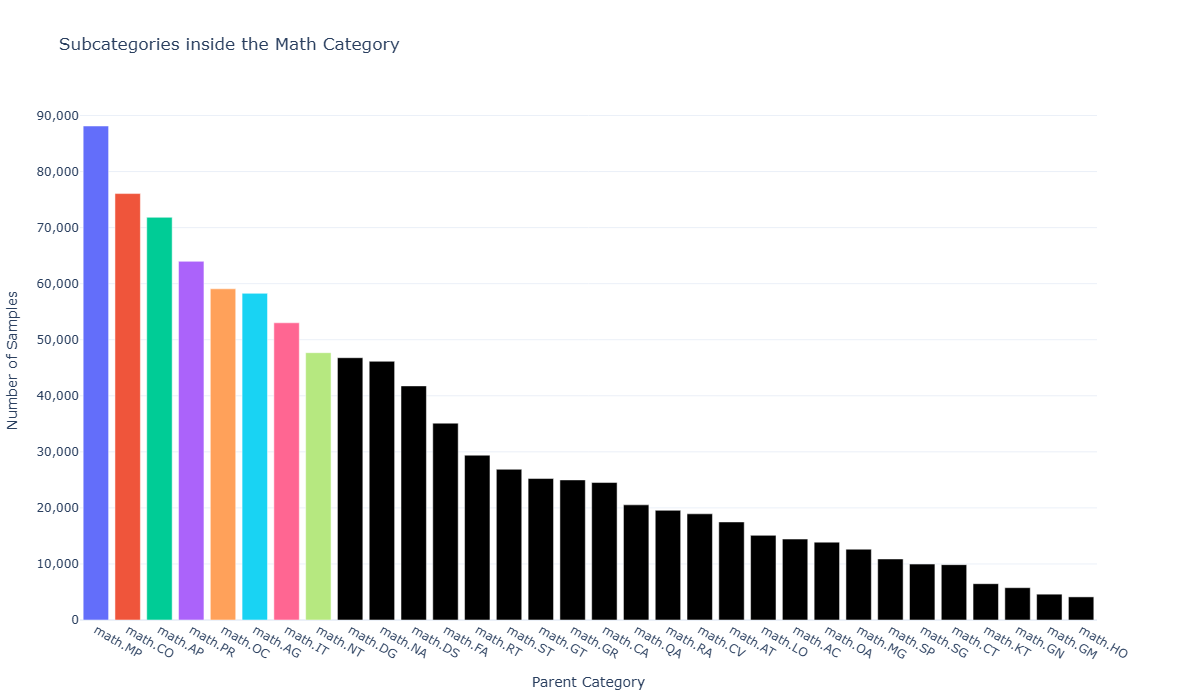

In [237]:
math_sub_cats_df = create_dfs_for_sub_category(df, "Mathematics")
plot_parent_distribution(math_sub_cats_df, "Math")

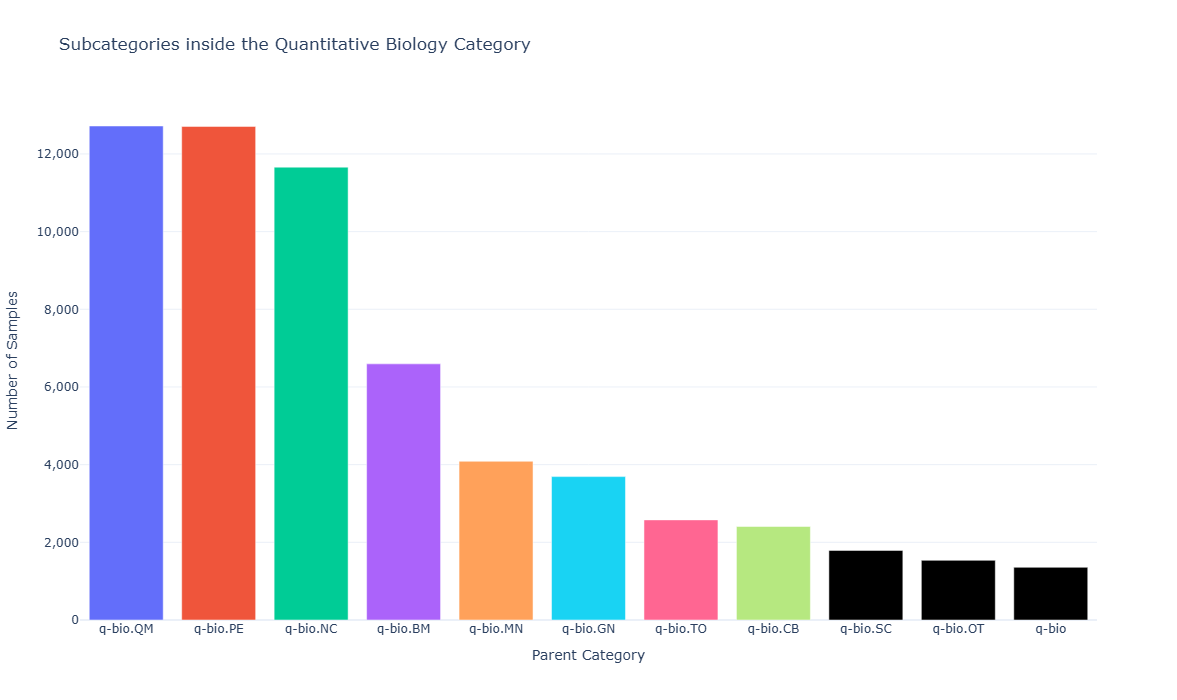

In [238]:
q_bui_sub_cats_df, min_cnt = create_dfs_for_sub_category(df, "Quantitative Biology")
plot_parent_distribution(q_bui_sub_cats_df, "Quantitative Biology")

### Manual checks

In [281]:
selected_category = 'Physics'
random_subcat_indices = pd.read_json(f"resources/train_indicies_{selected_category}_categories.jsonl", lines=True).to_numpy()

In [288]:
rand_row = random.randint(0, random_subcat_indices.shape[0])
rand_idx = random.randint(0, 1000)
print(f"Tag: {TARGET_SUB_CLASSES[selected_category][rand_row]}")
print(f"Rand sample: \n{json.dumps(ds[random_subcat_indices[rand_row][rand_idx]], indent=4)}")

Tag: physics.atom-ph
Rand sample: 
{
    "id": "1502.07239",
    "submitter": "Brendan McLaughlin Dr",
    "authors": "G Shen, P C Stancil, J G Wang, J F McCann and B M McLaughlin",
    "title": "Radiative charge transfer in cold and ultracold Sulfur atoms colliding\n  with Protons",
    "comments": "16 pages, 9 figures, accepted for publication in J Phys B: At. Mol.\n  Opt. Phys",
    "journal-ref": null,
    "doi": null,
    "report-no": null,
    "categories": "physics.atom-ph astro-ph.SR quant-ph",
    "license": "http://arxiv.org/licenses/nonexclusive-distrib/1.0/",
    "abstract": "  Radiative decay processes at cold and ultra cold temperatures for Sulfur\natoms colliding with protons are investigated. The MOLPRO quantum chemistry\nsuite of codes was used to obtain accurate potential energies and transition\ndipole moments, as a function of internuclear distance, between low-lying\nstates of the SH$^{+}$ molecular cation. A multi-reference\nconfiguration-interaction (MRCI) approx